In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Averaging filter for a sine function

In [2]:
def averaging(signal, nvals):
    return [sum(signal[i:i+nvals])/nvals  for i in range(len(signal)-nvals+1)]

print(averaging([1,2,3,4,5], 3))

[2.0, 3.0, 4.0]


[0.    0.001 0.002 ... 0.998 0.999 1.   ]


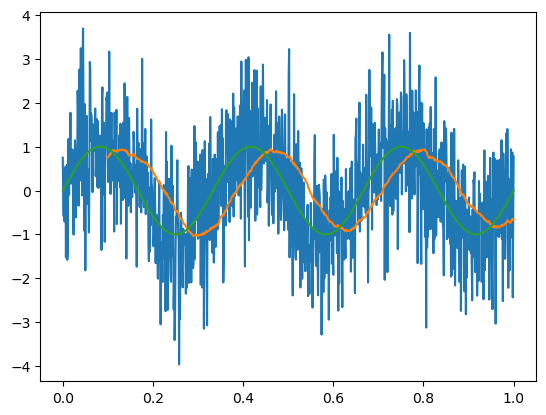

In [48]:
N = 1001
freq = 3

# Generem un senyal de prova
tvals = np.linspace(0, 1, N)
sig = np.sin(tvals*2*np.pi*freq)

# Afegim soroll blanc
mean = 0
std = 1
noise = np.random.normal(mean, std, size=N)

sig_noisy = sig + noise

nvals = 100
plt.plot(tvals, sig_noisy, label = "Noisy")
plt.plot(tvals[nvals-1:], averaging(sig_noisy, nvals), label = "Averaged")
plt.plot(tvals, sig, label = "Original")

print(tvals)

-103.7499999999999


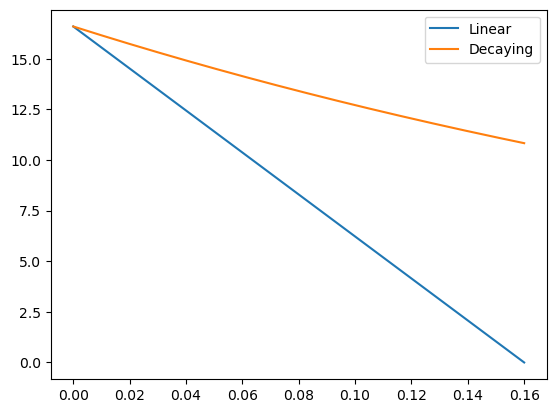

In [4]:
N2 = 501

simSlope = (0.1-16.7)/(16.96 - 16.8)
print(simSlope)
testx = np.linspace(0, 0.16, N2)
decay = lambda t : 16.6 *np.exp(-t*1e-3*0.08/(30e-6))

plt.plot(testx, 16.6 + testx*simSlope, label = "Linear")
plt.plot(testx, decay(testx), label = "Decaying")
plt.legend()

# Simulations show that the current of the floating branch decays at a rate of approximately -1.04e5 A/s

# Dynamic simulation of BLDC motor

### Electrical-mechanical coupling

The input signals are the Fase voltages. These can be modelled as a single, continuous PWM signal with a periodically-resetting current

The BEMF voltage obeys:

$$ V_{fase} - V_{BEMF_x} = L\cdot \frac{dI_x}{dt} + I_x \cdot R $$

And for the electrical (supplied) power:

$$ P = (V_{BEMF_x}) \cdot I_x \text{ (for phase x) } \to P = T_{mot} * \omega_{mot} $$

As for the mechanical power, using Newton's 2nd law:

$$ T_{mot} - T_{load} = J_{mot} \cdot \dot{\omega} + B_{mot} \cdot \omega \to \omega = \frac{1}{J_{mot}} \int_{t_0}^t (T_{mot} - T_{load}) dt - \frac{B_{mot}}{J_{mot}} \int_{t_0}^t \omega_{mot} dt $$

$T_{mot}$ is the same in both equations when the electrical supplied power is equal to the mechanical exerted power ($\mu=1$)

### Electrical simulation

In every instant, there is a closed branch through which current flows to power the motor. Let x and y be two of the three phases that comprise this branch at a given instant. Then:

$$ V_x(t) = L_x \frac{dI_x}{dt} + L_y \frac{dI_y}{dt} + I \cdot R_{par} = L_m \left( \frac{dI_x}{dt} + \frac{dI_y}{dt} \right) + (I_x + I_y)\cdot R_m $$

Assuming all branches are identical, with an inductance $L_m$ and a parasitic resistance of $R_m$, and neglecting other passive influences. The excitation signal $V_x(t)$ is always known (continuous PWM signal, which modulates the angular velocity with duty cycle): the problem now lies in finding the currents, $I_i$. However, this can be simplified using contour conditions. Namely, the global topology of the 

For that, the current flowing through the coils will be (ideally):

$$ \left. \begin{array}{rl}
I & \text{ for }V_x = V_{PWM}\\
0 & \text{ for floating } V_x\\
-I & \text{ for } V_x = 0V
\end{array} \right\} \text{ At any given time} \qquad \qquad \left. \begin{array}{rl}
0 & \text{ for }V_x = V_{PWM}\\
-I & \text{ for floating } V_x\\
0 & \text{ for } V_x = 0V
\end{array} \right\} \text{ Instantly after commutation} $$

Assuming that $V_x = V_{BEMF_x}$ when a branch is floating, the current flowing through it decays exponentially:

$$ I_f \cdot R + L \frac{dI_f}{dt} = 0 \to I(t) = I_0 e^{-tR/L} $$

Where $I_0$ is the maximum value of $I$ achieved during the previous state. Due to conservation of charge, we know that $\sum_i I_i = 0$. With this, the current flowing through a branch is reduced to a problem with time-periodic constraints:

$$ I_x + I_y + I_z = 0$$

Due to symmetry (six possible states, but now we are considering the three phases as one) the commutation is reduced to two possible states, plus the starter state. The system will switch between the following states 1 and 2, with the following initial conditions:

| State | I_x | I_anti | I_floating |
|:------:|:---:|:------:|:----------:|
|    0   |  0  |    0   |      0     |
|    1   |  0  |   -I   |      I     |
|    2   |  I  |    0   |     -I     |

Where $I_x$ corresponds to the high phase ($V_x=V(t)$) and $I_{anti}$ corresponds to the low phase.

Knowing this, the motor dynamics can be simulated by solving the following equations:
When the current at the floating branch is negligible, the voltage drop at an inductor will be equal to that of the other:
$$ V(t) = L_m \left( \frac{I_x - I_{x,prev}}{dt} + \frac{I_{anti} - I_{anti,prev}}{dt} \right) + (I_x + I_{anti}) \cdot R_m \to I_x + I_{anti} = 2\cdot I_x + I_{floating} = (V(t) - 2 \cdot R_m) \cdot dt / L_m + I_{x,prev} + I_{anti,prev} $$
$$  I_{floating} = I_0 -1.04e5 \cdot t \qquad \sum_i I_i = 0 $$

Therefore, each step may be computed in the order $I_{floating} \to I_x \to I_{anti}$.

In [66]:
def PWMCycle(duty):
    """
    Defines a PWM cycle array with a resolution of 1ms
    """
    return [1 if (i < duty * 1e3) else 0 for i in range(1,1001)]

def PWMState(time, period, duty):
    """
    Given a time measure (and assuming t_0 = 0), returns the state of a PWM signal
    """
    cycleTime = time % period

    if cycleTime <= duty * period:
        return 1
    else:
        return 0

In [174]:
def getStarCurrent(Vin, duty, time, phasePeriod, dt, I_0, Iprev):
    """
    Returns the currents going through the branches of the motor's star at a given instant, for previous values and a given duty cycle
    """
    R_m = 0.08 # Ohm
    L_m = 30e-6 # H
    A = (1 + R_m * dt / L_m)
    Vmax = 12 #V
    PWMPeriod = 1/30e3 # Hz
    #Vin = Vmax * PWMState(time, PWMPeriod, duty)

    phaseTime = time % (phasePeriod * 2)
    firstPhase = phaseTime < phasePeriod
    phaseTime %= phasePeriod
    if phaseTime < 0.2e-3:
        if firstPhase:
            I_floating = I_0 - 103750 * phaseTime
        else:
            I_floating = -I_0 + 103750 * phaseTime
    else:
        I_floating = 0

    if firstPhase and I_floating < 0:
        I_floating = 0
    elif not(firstPhase) and I_floating > 0:
        I_floating = 0

    # IDGAF model: V_x - V_n = IR+ LdI/dt -> I_x:
    V_n = getVn(duty, time, 1.2e-3, 0.2e-3)
    #I_x = ((Vin - V_n) * dt / L_m + Iprev[0])/A # FOR SOME REASON AIXO FUNCIONA

    I_x = (Vin * dt / L_m + Iprev[0] - Iprev[1]) / (2*A) - I_floating/2 # FOR SOME REASON AIXO TAMBE? NO ENTENC EL SIGNE PERO BUENO

    I_anti = - I_floating - I_x

    #V_x = I_x * R_m + L_m * (I_x - Iprev[0]) / dt
    V_x = 1

    return [I_x, I_anti, I_floating], V_x

def getVn(duty, time, phasePeriod, decayTime):
    Vpwm = 3.3
    PWMPeriod = 30e3

    if time % 2*phasePeriod < phasePeriod:
        if time % phasePeriod < decayTime:
            return PWMState(time, PWMPeriod, duty)
        else:
            return 2*PWMState(time, PWMPeriod, duty)
    else:
        if ((time % 2*phasePeriod) - phasePeriod) < decayTime:
            return PWMState(time, PWMPeriod, duty)
        else:
            return 3/2 * PWMState(time, PWMPeriod, duty)

[0.0000e+00 3.6000e-06 7.2000e-06 ... 7.1928e-03 7.1964e-03 7.2000e-03]
dt =  3.5999999999999994e-06
PWMPeriod =  3.3333333333333335e-05
SWITCH


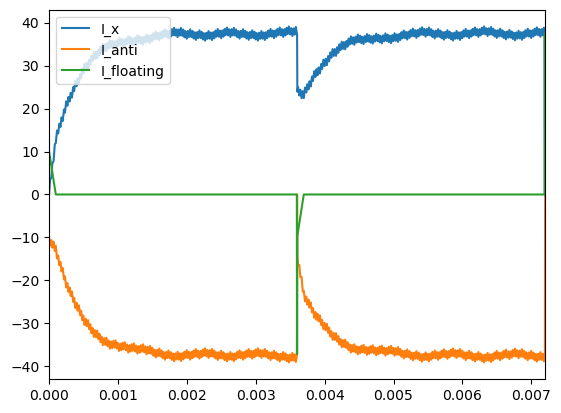

In [197]:
N2 = 2000

tfin = 1.2*6
# Time values
Ints = np.zeros((N2+1,3))
times = np.linspace(0, tfin*1e-3, N2+1)
dt = tfin/N2*1e-3
print(times)
duty = 0.5
time = 0
PWMPeriod = 1/30e3 # s
phasePeriod = 1.2e-3*3 # s
print("dt = ", dt)
print("PWMPeriod = ", PWMPeriod)
PWM = [PWMState(item, PWMPeriod, duty)*5 for item in times]
I_0 = 10
# Initial conditions
Ints[0] = [0.0, -I_0, I_0]


for i in range(1,N2):
    time += dt
    Vin = PWMState(time, PWMPeriod, duty) * 12

    Intsnew, V_x = getStarCurrent(Vin, duty, time, phasePeriod, dt, I_0, Ints[i-1])
    Ints[i] = Intsnew
    #Ints[i] = [item/2 for item in Ints[i]]

    phaseTime = time % (phasePeriod * 2)
    firstPhase = phaseTime < phasePeriod
    phaseTime %= phasePeriod
    if abs(phaseTime - phasePeriod) <= dt:
        if firstPhase:
            Ints[i] = [-Ints[i,1], 0.0, Ints[i,1]]
        else:
            print("SWITCH")
            Ints[i] = [0.0, Ints[i,1], -Ints[i,1]]


plt.plot(times, Ints[:,0], label = "I_x")
plt.plot(times, Ints[:,1], label = "I_anti")
plt.plot(times, Ints[:,2], label = "I_floating")
#plt.plot(times, PWM, label = "PWM")
plt.xlim(0, tfin*1e-3)
plt.legend()

In [ ]:
# Motor transfer function (H(s) = w(s)/V(s))
# Recall that PID reads angular frequency and returns duty cycle

def motorWang(Vfase, V_x, dt, prevWang, acumWang, acumTdiff):
    J = 1e-6
    B = 2e-3
    Tload = 1e-2
    Rs = 0.8 # Ohm
    Ls = 1 # H

    time
    V_n 
    Vbemf = Vfase - V_x - V_n
    
    Power = (V_x - V_n) * I_x
    Tmot = Power / prevWang
    Tdiff = Tmot - Tload

    newWang = 1/J * (Tdiff + acumTdiff) * dt # First integral
    newWang -= B/J * (prevWang + acumWang) # Second integral

    return newWang, Tdiff


In [28]:
# Define setpoint array for a step input
setpoint = np.ones(N) * 2
setpoint[0] = 1

In [29]:
# PID step function
def PID_step(errNew, errPrev, errAcum):
    dt = 0.001
    Kp = errNew * 0.005
    Ki = (errNew + errAcum) * dt * 0
    Kd = (errNew - errPrev) / dt * 0
    return Kp + Ki + Kd

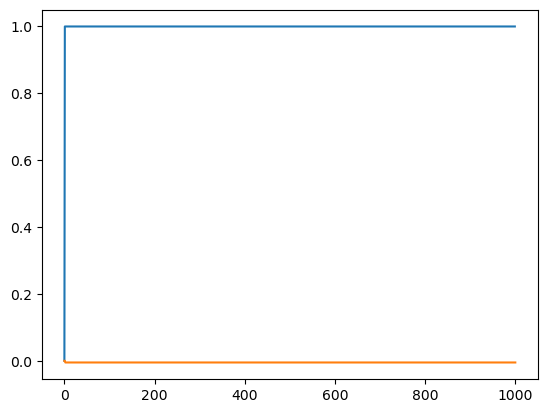

In [25]:
tmax = 50e-3
dt = tmax / N

# Find PID response
errPrev = 0
errAcum = 0
outVals = np.ones(N)
outVals[0] = 0

for i in range(1,N):

    # Compute PID step
    errNew = outVals[i-1] - setpoint[i-1]
    errAcum += errNew
    outVals[i] = PID_step(errNew, errPrev, errAcum)
    errPrev = errNew
    #print(errNew)

    # Duty cycle -> voltage
    duty = outVals[i]
    Vin = duty * 12 # V

    newWang, Tdiff = motorWang(Vin, dt, )

    # Simulate motor dynamics
    

plt.plot(setpoint)
plt.plot(outVals)